# nb12 — Paired Multiome RNA + ATAC integration with MultiVI

Jointly model RNA and genomic peak counts from the eight eligible nb09 donors.
No pathway selection, labels as supervision, donor/site correction, or CITE input.
This learns a within-Multiome representation. It does not align to totalVI coordinates.

Use TRAIN once in a fresh GPU runtime and output folder. Return with LOAD (default)
to view saved results without training or raw data. Use EVALUATE if analysis was
interrupted after model saving. Run independently of the active nb11 runtime.
Copy this notebook and src/multivi_workflow.py to the existing Drive repository;
existing src helpers remain dependencies. nb01–11 are unchanged.

In [2]:
from pathlib import Path
import json, sys, subprocess
MODE = 'TRAIN'  # TRAIN for first run; EVALUATE to rebuild analysis without training
assert MODE in {'LOAD','TRAIN','EVALUATE'}
try:
    from google.colab import drive
    IN_COLAB=True
except ImportError:
    IN_COLAB=False
if IN_COLAB:
    drive.mount('/content/drive')
    BASE=Path('/content/drive/MyDrive/multiomics-relationship-modeling')
else:
    BASE=Path.cwd().resolve()
    if not (BASE/'src').is_dir(): BASE=BASE.parent
if MODE != 'LOAD':
    subprocess.check_call([sys.executable,'-m','pip','install','-q',
        'scanpy>=1.11,<1.12','scvi-tools>=1.3,<1.5','anndata>=0.11,<0.13'])
sys.path.insert(0,str(BASE))
import pandas as pd
from IPython.display import display,Image
OUTPUT=BASE/'results/multivi/nb12_run01'
COHORT=BASE/'results/cross_donor/nb09_run01'
SEED=42
N_HVGS=3000
MAX_PEAKS=20000
MIN_PEAK_CELLS=50
TRAINING=dict(max_epochs=300,min_epochs=100,warmup_epochs=50,patience=30,
              accelerator='auto',batch_size=128,n_latent=30)
print('Mode:',MODE,'Output:',OUTPUT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Mode: TRAIN Output: /content/drive/MyDrive/multiomics-relationship-modeling/results/multivi/nb12_run01


## Input checks and feature selection
Authenticate the Multiome input and nb09 cohort/mapping by hashes. Read raw
layers/counts in bounded row chunks. RNA and ATAC stay paired by source cell ID.
Cells need positive RNA and peak totals; exclusions are audited. Unique genomic
peaks are required. Existing gene-activity matrices are not used.

RNA: up to 3,000 HVGs from log1p CP10k expression with equal donor quotas.
ATAC: peaks detected in at least 50 eligible cells; retain up to 20,000 with highest
pooled detection prevalence (stable ties). This computational starting choice may
underrepresent rare cell states and favor abundant populations. Inspect peak_audit.csv.
Cells with no counts in selected peaks are excluded and logged. Counts remain sparse.

The combined model input stores raw RNA first and raw peaks second, with explicit
n_genes/n_regions. At training/reload it is reconstructed as paired RNA/ATAC MuData
using setup_mudata, with cell order checked. MultiVI models peak detection/accessibility, not a quantitative
fragment-count likelihood. RNA uses NB. No labels, donor/site nuisance covariates
or adversarial batch mixing. Hidden width 128, latent size 30. The cohort is fully
paired; no missing modality is invented. Separate modality encoders use MultiVI's
default alignment penalty.

50-epoch KL warm-up, minimum 100 / maximum 300 epochs. A callback monitors validation
ELBO after warm-up with patience 30. Final weights are saved, not restored best weights.
No convergence or biological success is assumed from reaching the epoch limit.

[MultiVI documentation](https://docs.scvi-tools.org/en/1.4.3/tutorials/notebooks/multimodal/MultiVI_tutorial.html)

In [3]:
if MODE == 'TRAIN':
    from configs.paths import MULTIOME_H5AD
    from src.multivi_workflow import run_multivi
    run_multivi(MULTIOME_H5AD,COHORT,OUTPUT,seed=SEED,n_hvgs=N_HVGS,
                max_peaks=MAX_PEAKS,min_peak_cells=MIN_PEAK_CELLS,**TRAINING)
elif MODE == 'EVALUATE':
    from src.multivi_workflow import evaluate_saved
    evaluate_saved(OUTPUT,seed=SEED)
else:
    print('Training skipped; reading saved results next.')

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
/usr/local/lib/python3.13/dist-packages/torch/nn/modules/linear.py:124: UserWarning: Initializing zero-element tensors is a no-op
  init.kaiming_uniform_(self.weight, a=math.sqrt(5))
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning

Training:   0%|          | 0/300 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 30 records. Best score: 6858.592. Signaling Trainer to stop.


In [4]:
files=['metric_comparison.csv','celltype_metrics.csv','depth_associations.csv']
missing=[name for name in files if not (OUTPUT/name).exists()]
if missing:
    raise FileNotFoundError(f'Missing {missing}. First run: choose TRAIN. If model/model.pt '
                            'and model_input.h5ad exist, choose EVALUATE, not TRAIN.')
comparison,types,depths=[pd.read_csv(OUTPUT/name) for name in files]
for name in ['status.json','evaluation_status.json','input_audit.json','training_summary.json']:
    if (OUTPUT/name).exists():
        print(name);display(json.loads((OUTPUT/name).read_text()))

status.json


{'state': 'complete', 'biological_review': 'required'}

evaluation_status.json


{'state': 'complete',
 'n_evaluation_cells': 18424,
 'outputs_sha256': {'peak_audit.csv': '0f29759fc899f1e6192db74b6bbb41d09e66401259d1b36e638e6458b66fa8f4',
  'cell_audit.csv': '7e0e968c8dad66530601792eac90b23a8798b72e3676424d9fffb6dac8645398',
  'hvg_audit.csv': 'd1f1c4a0267e61e3c0e3da68454088dcc647bdea2e169595dbd2ba41ebba771c',
  'counts_by_DonorID.csv': '94c9e81af953a954706d700ff7a0cdc85560ce190e1e75cca934cbba00434395',
  'counts_by_Site.csv': 'a9576e88bdaecf3d65c25d006173a46c2256618f4202eb62f69bad59a3fdadb1',
  'counts_by_cell_type_harmonized.csv': '88da4a2c8079d4e008c6923549b0de8c7617997b8f37b8c174248380130aef64',
  'training_kl_weight.csv': '4cc7754d773a91be01b2415eebaca151ab38702baf3c94e2bedbf5e37a88a312',
  'training_validation_loss.csv': '992879d25c4dd2f914de757ee88cc3862d403e245d9e6d17e0f9c0abca5e8ad4',
  'training_elbo_validation.csv': 'de90c5fc6825c4d673654103ce488a6ef95087cf0f183f3d11b19da3f7a8b15a',
  'training_reconstruction_loss_validation.csv': 'c98aa1cd47f969f963ba7f

input_audit.json


{'source': {'path': '/content/drive/MyDrive/multiomics-relationship-modeling/data/benchmark/GSE194122_openproblems_neurips2021_multiome_BMMC_processed.h5ad',
  'file_bytes': 3116868580,
  'file_mtime_ns': 1782768739000000000,
  'shape': [69249, 129921],
  'feature_types': {'ATAC': 116490, 'GEX': 13431},
  'repeated_feature_names': [],
  'feature_name_policy': 'Select GEX by column position; require unique RNA symbols only',
  'layers': ['counts'],
  'obsm': ['ATAC_gene_activity',
   'ATAC_lsi_full',
   'ATAC_lsi_red',
   'ATAC_umap',
   'GEX_X_pca',
   'GEX_X_umap'],
  'X_encoding': 'csr_matrix',
  'rna_source': 'layers/counts restricted to GEX before normalization'},
 'donors': ['10886',
  '11466',
  '12710',
  '15078',
  '16710',
  '18303',
  '19593',
  '28045'],
 'n_cells': 58143,
 'n_genes': 3000,
 'n_peaks': 20000,
 'excluded_cells': 0,
 'peak_selection': 'Detected in >= min_peak_cells; most prevalent up to max_peaks, stable ties, original order. May underrepresent rare states.',


training_summary.json


{'epochs_completed': 121,
 'best_validation_epoch': 90,
 'final_validation_elbo': 6859.54150390625,
 'final_kl_weight': 1.0,
 'reached_epoch_limit': False,
 'warmup_epochs': 50,
 'note': 'Final weights, not restored best checkpoint. Review curves and biology.'}

## Training and three-way biological comparison
Compare RNA PCA, ATAC LSI and MultiVI on the same fixed donor-quota sample (up to
20,000 resolved cells). Labels evaluate but never train the model. Rare-type sample
sizes are reported; unresolved labels remain in training and are excluded here.
Silhouette uses at most 3,000 cells. No cell-level inferential p-values.

RNA PCA uses log1p CP10k normalized across all GEX before HVG selection. ATAC LSI
uses binary selected peaks, row term frequency and log1p(N/detection count) inverse
document frequency, then truncated SVD. LSI1 is dropped a priori; remaining depth
associations are still inspected. Neither baseline is fed to MultiVI training.

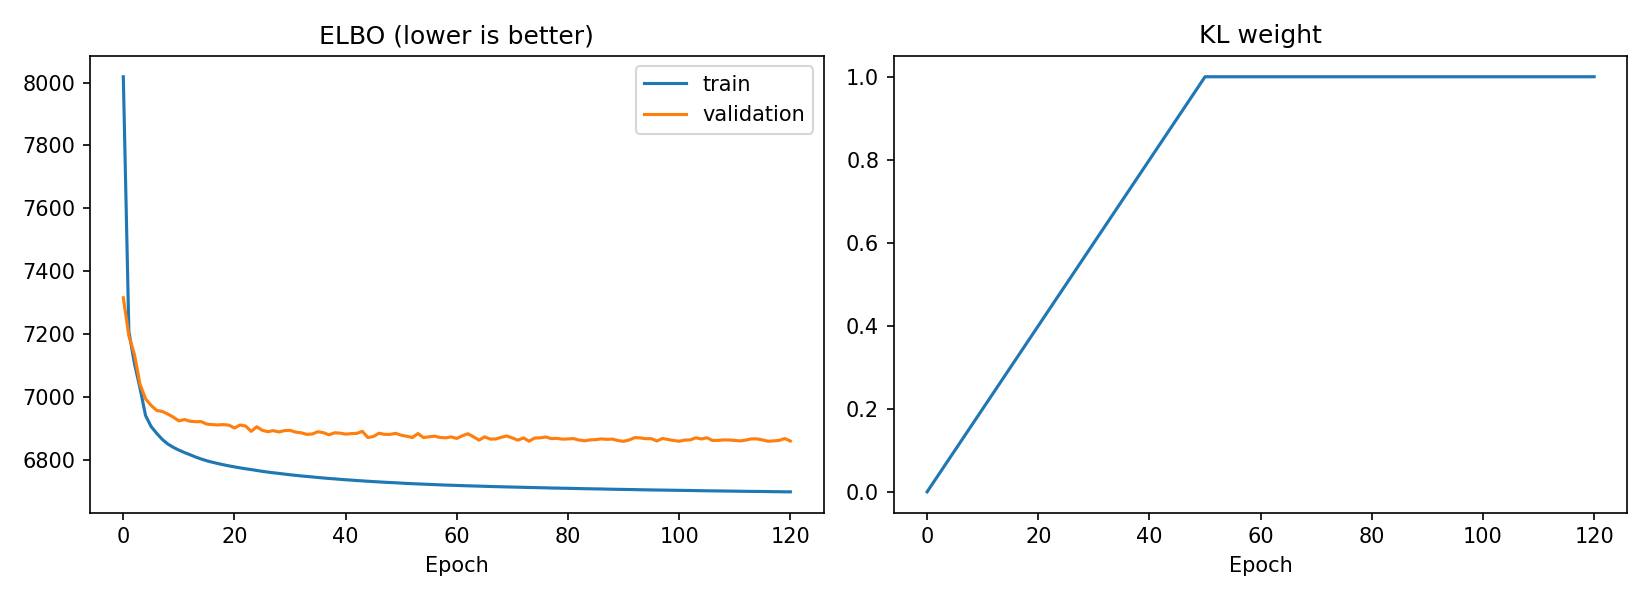

,metric,rna_pca,atac_lsi,MultiVI,change_vs_rna,change_vs_atac
0,cell_type_purity,0.876058,0.767857,0.884285,0.008227,0.116428
1,cell_type_entropy,0.087545,0.160044,0.078734,-0.008811,-0.081310
2,cell_type_knn_label_agreement,0.926672,0.846450,0.926672,0.000000,0.080221
3,cell_type_silhouette,0.132020,-0.008893,0.150318,0.018298,0.159211
4,donor_purity,0.662761,0.354673,0.630022,-0.032738,0.275349
5,donor_entropy,0.341348,0.595600,0.347429,0.006081,-0.248171
6,donor_knn_label_agreement,0.796461,0.456687,0.742673,-0.053789,0.285986
7,donor_silhouette,-0.005717,-0.096650,-0.001120,0.004596,0.095529
8,site_purity,0.836847,0.548614,0.850771,0.013924,0.302157
9,site_entropy,0.242464,0.536013,0.198162,-0.044301,-0.337851


,cell_type_harmonized,cell_type_purity,cell_type_entropy,cell_type_knn_label_agreement,cell_type_silhouette,donor_purity,donor_entropy,donor_knn_label_agreement,donor_silhouette,site_purity,site_entropy,site_knn_label_agreement,site_silhouette,n_evaluation_cells,space
0,B cells,0.970293,0.017543,0.976306,0.133003,0.605029,0.403612,0.776596,0.000975,0.821099,0.283278,0.921663,0.034673,2068,rna_pca
1,CD14 monocytes,0.963431,0.031945,0.986264,0.168137,0.707194,0.303602,0.830891,-0.062656,0.845981,0.223783,0.915140,0.017391,3276,rna_pca
2,CD16 monocytes,0.865303,0.087257,0.903885,0.293413,0.739332,0.263918,0.828221,-0.034240,0.859714,0.194825,0.895706,0.016926,489,rna_pca
3,CD4 T cells,0.841459,0.113309,0.918964,0.121350,0.665972,0.348780,0.816409,-0.001886,0.850224,0.229991,0.932751,0.032403,2974,rna_pca
4,CD8 T cells,0.837009,0.115636,0.907139,0.011219,0.784871,0.219300,0.881602,0.031605,0.920913,0.125142,0.965177,0.055723,3446,rna_pca
5,Erythroid populations,0.980065,0.016645,0.991124,0.293164,0.593942,0.379125,0.686391,0.024617,0.757946,0.320751,0.835165,0.029728,2366,rna_pca
6,G/M progenitors,0.535425,0.320575,0.674510,-0.011413,0.581699,0.478324,0.788235,-0.040010,0.770327,0.360376,0.901961,0.031549,255,rna_pca
7,HSC,0.620363,0.279738,0.793774,0.164287,0.505318,0.520112,0.704280,-0.014173,0.755512,0.361095,0.883268,0.038539,257,rna_pca
8,ILC,0.375556,0.257214,0.409524,0.062572,0.601746,0.407976,0.771429,0.025703,0.812381,0.288584,0.919048,0.015431,210,rna_pca
9,Lymphoid progenitors,0.736047,0.197365,0.834302,0.136520,0.548353,0.487987,0.773256,0.008004,0.727713,0.469429,0.915698,0.024908,344,rna_pca


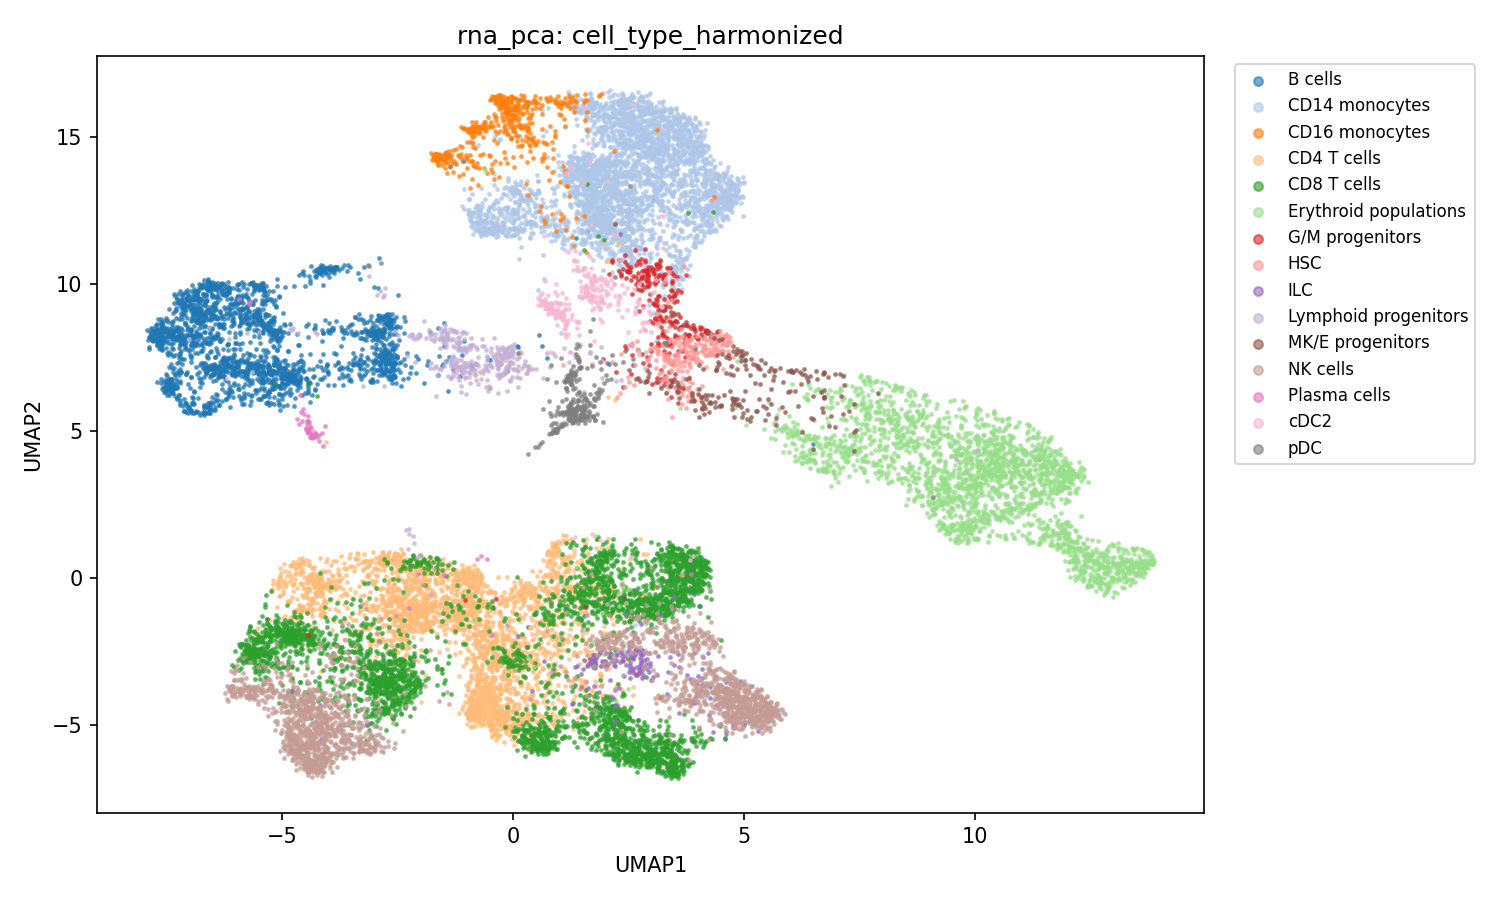

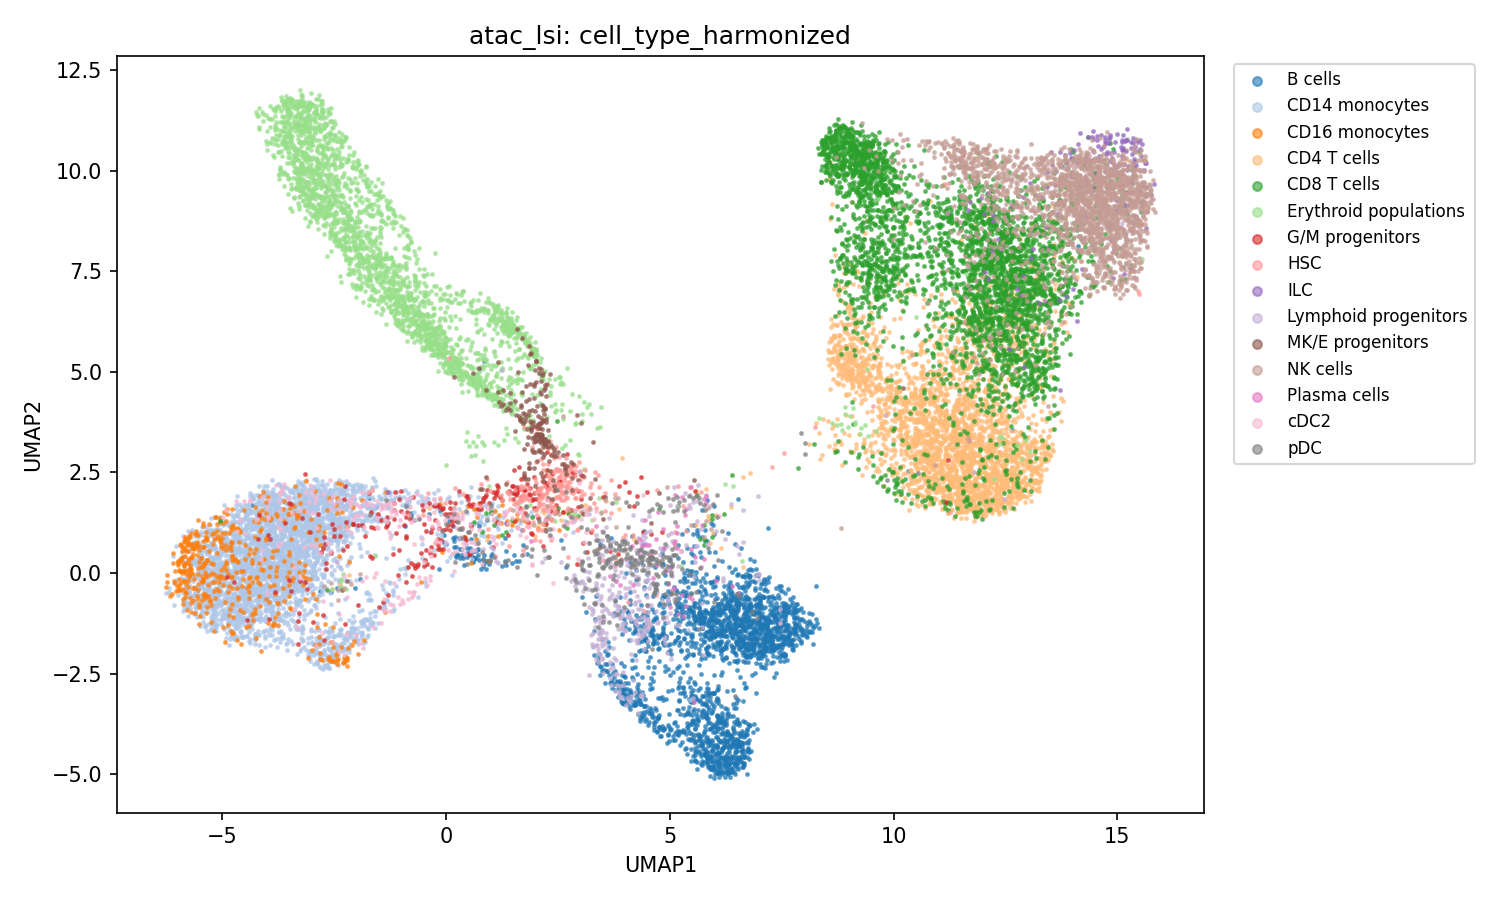

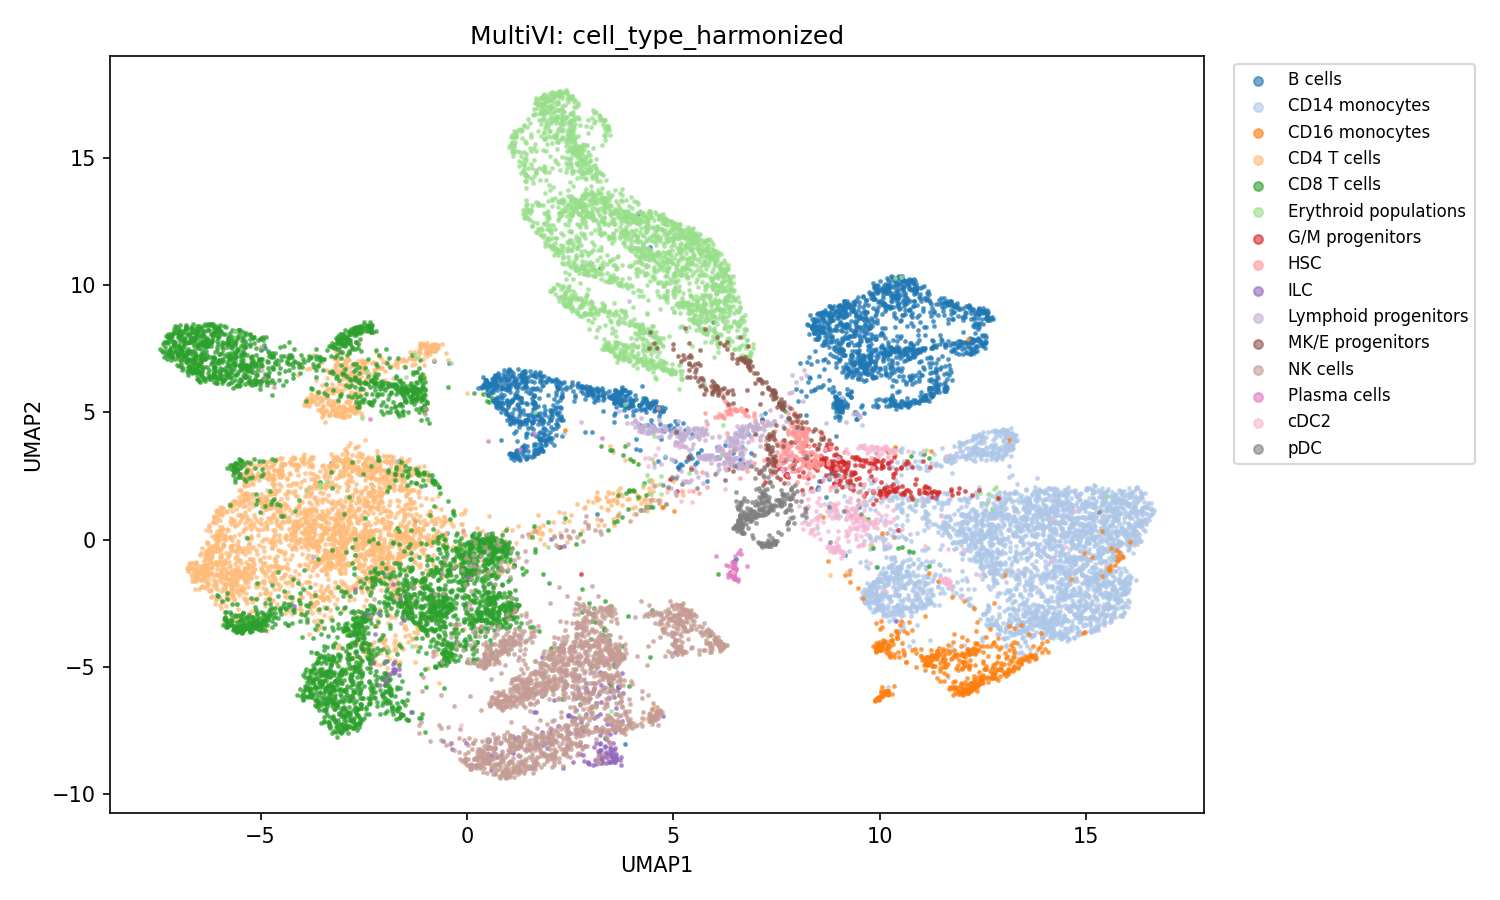

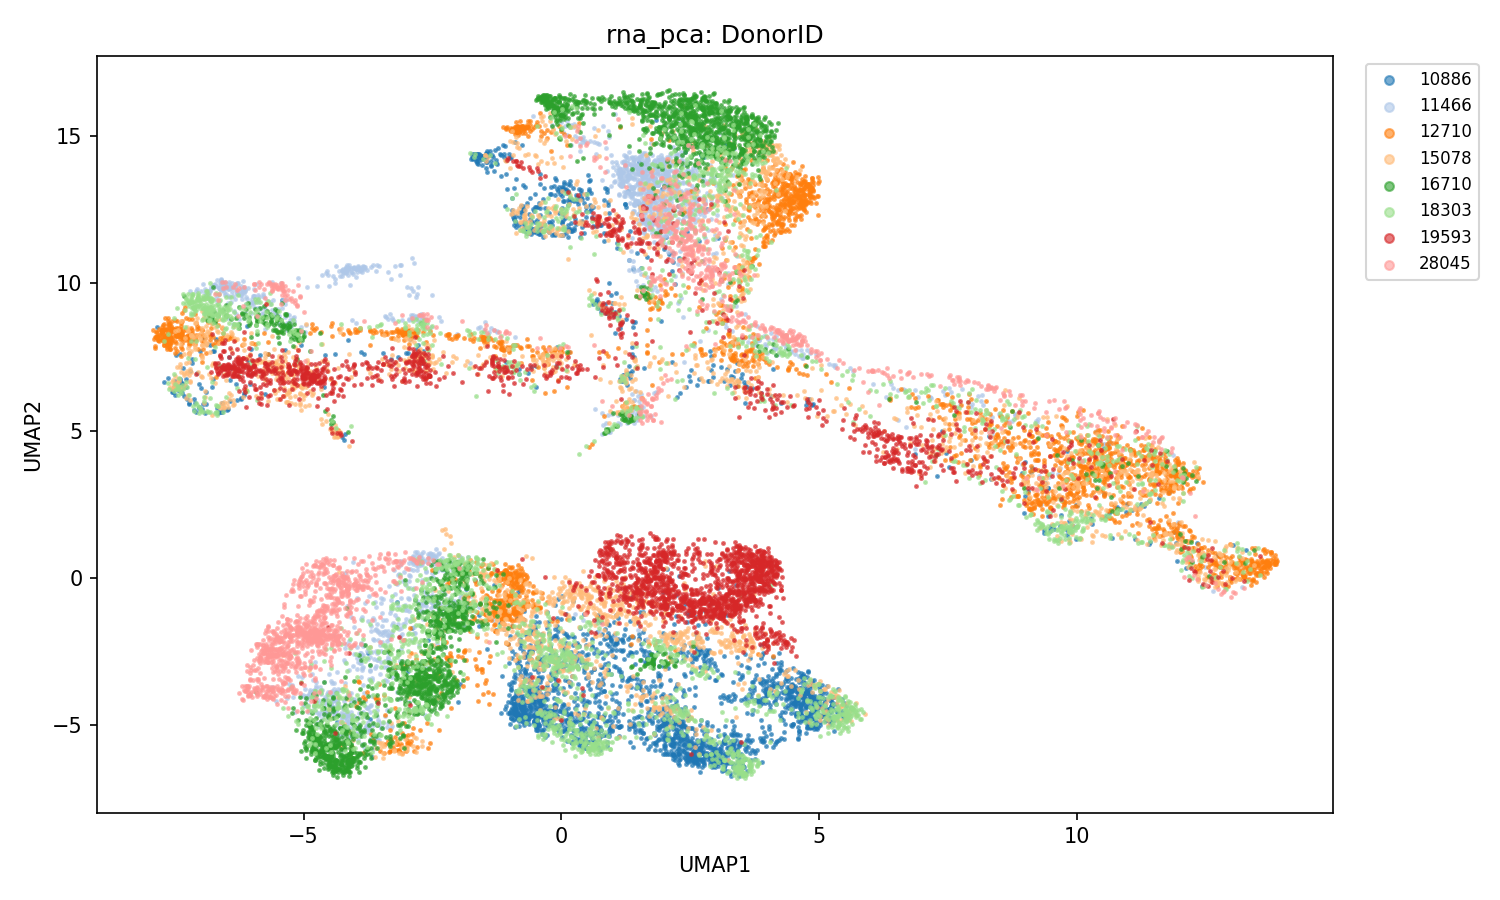

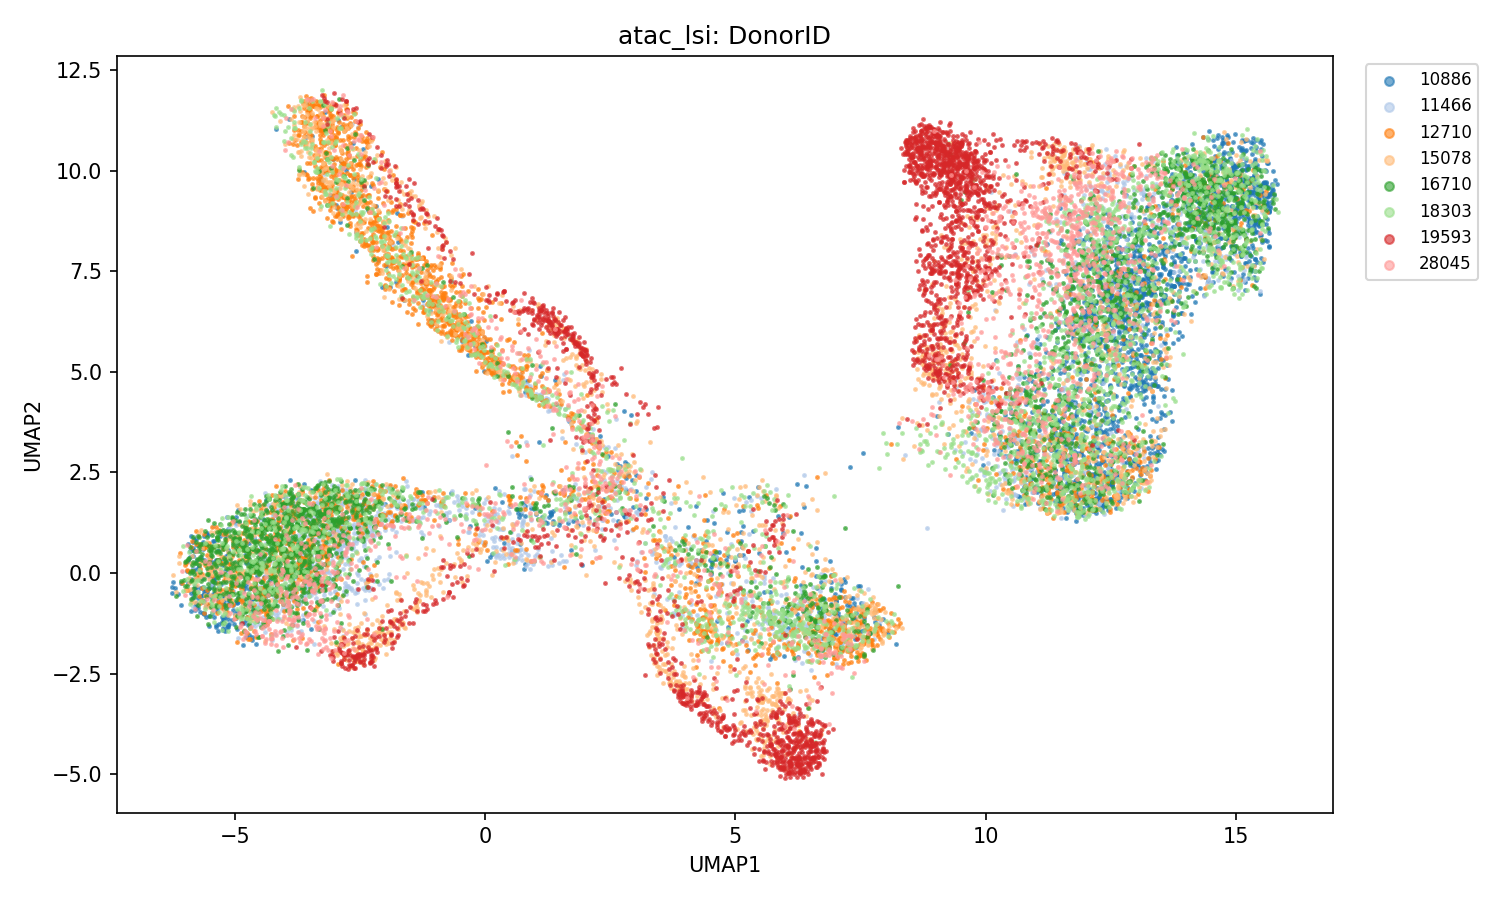

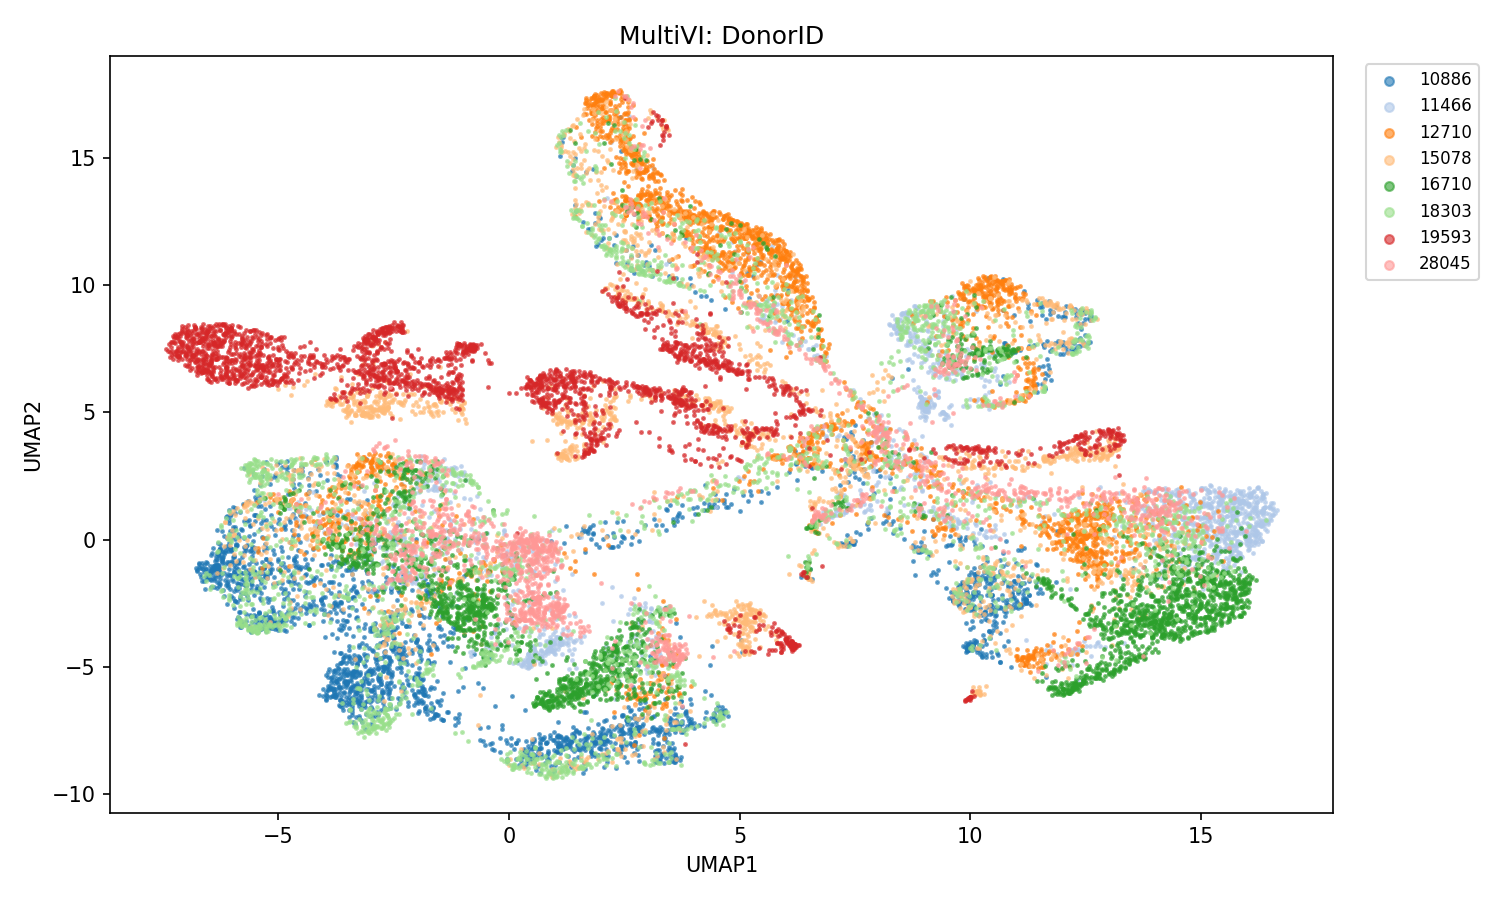

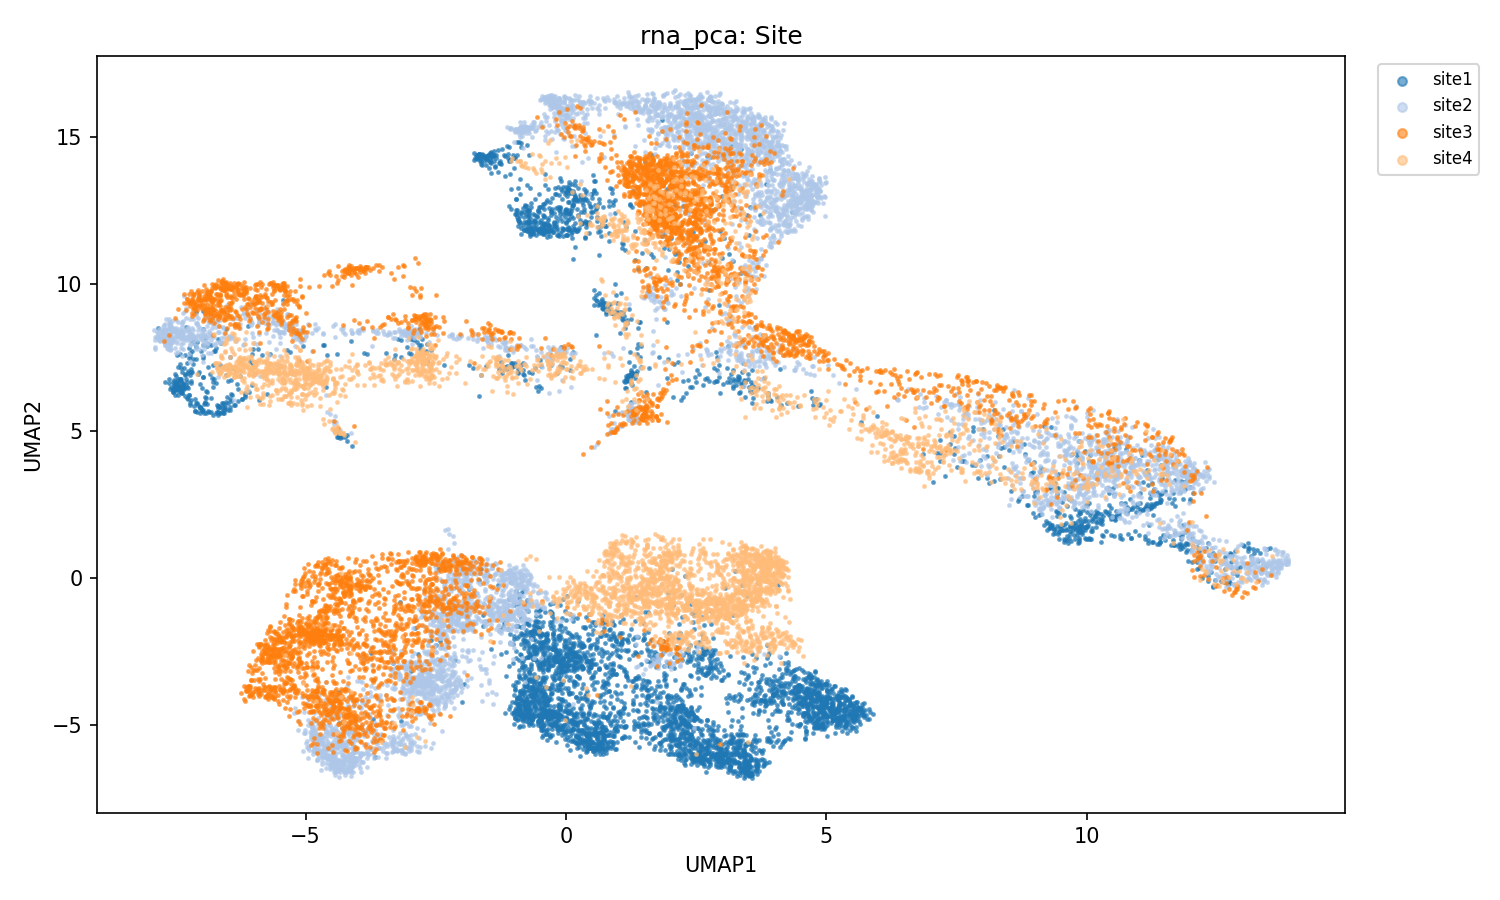

In [5]:
display(Image(filename=str(OUTPUT/'figures/training.png')))
display(comparison)
with pd.option_context('display.max_rows',None):display(types)
for field in ['cell_type_harmonized','DonorID','Site']:
    for space in ['rna_pca','atac_lsi','MultiVI']:
        display(Image(filename=str(OUTPUT/f'figures/{space}_{field}.png')))
display(depths)

## Interpretation after execution
Record convergence, broad cell identity and rare-population behavior relative to
both baselines. Check donor/site structure and depth associations; mixing is not
an optimization target. Coordinate/depth correlations are descriptive and depend
on the coordinate system. UMAP agreement is not independent biological validation.
No pathway-specific conclusion, held-out accessibility accuracy or causal claim
is inferred. Generalization beyond these donors remains untested.

## Saved results and next step
model_input.h5ad stores one sparse raw RNA+peak matrix, ordered features, metadata,
RNA PCA, ATAC LSI and joint coordinates. model/ stores weights/registry; histories,
audits, CSVs and ten PNG figures are saved separately. The input is written before
training and weights before analysis. EVALUATE can recover latent coordinates
from weights if training finished before coordinates were saved. LOAD reads only
saved outputs; no dependence on previous session variables.

Review totalVI and MultiVI separately before considering cross-capture integration.
Their latent axes are unrelated and cannot be directly concatenated. Neither
notebook identifies matching CITE/Multiome cells.